# Margen del coeficiente: cuánto queda por ganar en T8

**Experimento de apoyo.** No forma parte del anexo de código del TFM.
Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019). Carlos J. Bravo I.

Este cuaderno acompaña al de la Configuración 1 y responde a una sola pregunta: **cuánto del error
que queda en T8 es atribuible al coeficiente de la ley de crecimiento, y cuánto al resto del
modelo**. Para responderla congela el estimador ya entrenado y sustituye únicamente ese coeficiente.

> **Qué es esto y qué no es.** El coeficiente que se usa aquí para T8 se obtiene **mirando su curva
> real**, que es justamente lo que el certamen pide predecir. No es, por tanto, un método: ningún
> resultado de este cuaderno puede entregarse como predicción ni compararse de igual a igual con las
> cifras publicadas del certamen. Es un **análisis de oráculo**, un género habitual en evaluación de
> modelos, que mide el techo alcanzable si un mecanismo futuro lograra identificar ese coeficiente
> a partir de información disponible en el momento de predecir. Su función es cuantificar el margen
> que justifica las Configuraciones 2 a 4, y acotar cuánto de la penalización de T8 **no** se debe
> al coeficiente y seguiría ahí aunque se acertara.

> **Asimetría deliberada entre probetas.** T7 conserva el coeficiente que el modelo identifica por
> sí solo. Sólo T8 recibe el coeficiente de oráculo. Esa asimetría es el objeto del estudio: T7 es de
> amplitud constante y su coeficiente cae dentro de la banda admisible, mientras que T8 es de carga
> por bloques y el suyo cae fuera.

In [1]:
import sys
import time
import warnings
from pathlib import Path

RAIZ = next(d for d in (Path.cwd(), *Path.cwd().parents)
            if (d / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings("ignore")
torch.set_num_threads(4)
pd.set_option("display.width", 170)

from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import ABLATION, REFERENCES, build_submission
from config1_cnn_pinn.t8_study import sweep_coefficient, trajectory
from config1_cnn_pinn.train import Config, TRAIN_POOL, train_ensemble
from physics_calibration.data import load_curve
from physics_calibration.objectives import phm_penalty


def marca_de_agua(fig):
    fig.text(0.99, 0.01, "Carlos J. Bravo (2026)", color="0.45", alpha=0.38,
             fontweight="bold", ha="right", va="bottom", fontsize=8)


def eje_decimal(ax):
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.yaxis.set_minor_formatter(StrMethodFormatter("{x:g}"))


def cerrar(fig):
    marca_de_agua(fig)
    fig.tight_layout()
    plt.show()

## 1. El modelo de partida

Se entrena exactamente la Configuración 1, con la misma configuración, las mismas semillas y el
mismo protocolo. Nada de este cuaderno modifica el estimador: lo único que cambiará, y sólo en T8,
es el coeficiente con el que se propaga la grieta más allá del último ciclo con señal.

In [2]:
cfg = Config(**ABLATION["Configuración 1 (1D-CNN + PINN)"])
etiquetas = load_labels()
lotes = build_specimen_batches(etiquetas, cfg.m_exponent)

t0 = time.perf_counter()
modelos = train_ensemble(cfg, lotes, [n for n in TRAIN_POOL if n in lotes], n_seeds=5)
print(f"ensamblado de {len(modelos)} semillas en {time.perf_counter() - t0:.0f} s")

entregas = {n: build_submission(modelos, lotes, cfg, n) for n in ("T7", "T8")}
base = pd.DataFrame([{
    "espécimen": n,
    "log10 C del modelo": round(e["log10_C_predicho"], 3),
    "log10 C que implica la curva": round(e["log10_C_implicado"], 3),
    "penalización": round(e["penalizacion"], 2),
    "RMSE (mm)": round(e["rmse_mm"], 3),
} for n, e in entregas.items()])
display(base)

ensamblado de 5 semillas en 134 s


,espécimen,log10 C del modelo,log10 C que implica la curva,penalización,RMSE (mm)
0,T7,-8.423,-8.420,6.49,0.350
1,T8,-8.423,-8.803,90.45,2.418


## 2. Barrido del coeficiente sobre T8

Con el estimador congelado, se recorre el coeficiente y se reconstruye la entrega completa con cada
valor. La curva resultante tiene tres puntos de interés que conviene no confundir: el coeficiente
que el modelo emite, el que implica la curva medida completa y el que minimiza la penalización
oficial.

In [3]:
barrido = sweep_coefficient(modelos, lotes, cfg, "T8")
e8 = entregas["T8"]

candidatos = {
    "el que emite el modelo": e8["log10_C_predicho"],
    "el que implica la curva completa": e8["log10_C_implicado"],
    "el que minimiza el error en mm": float(barrido.loc[barrido["rmse_mm"].idxmin(), "log10_C"]),
    "el que minimiza la penalización": float(barrido.loc[barrido["penalizacion"].idxmin(), "log10_C"]),
}

ESTILO = dict(zip(candidatos, (("tab:blue", (0, (6, 3))),
                               ("tab:orange", (0, (2, 2))),
                               ("tab:green", (0, (1, 1.6))),
                               ("tab:red", (0, (7, 2, 1.5, 2))))))

curva8 = load_curve("T8")
filas = []
for nombre, log_c in candidatos.items():
    pred = trajectory(modelos, lotes, cfg, "T8", log_c)
    filas.append({
        "coeficiente": nombre,
        "log10 C": round(log_c, 3),
        "C": f"{10 ** log_c:.3e}",
        "penalización": round(float(phm_penalty(pred[None, :], curva8.crack_mm,
                                                curva8.final_crack_mm)[0]), 2),
        "RMSE (mm)": round(float(np.sqrt(np.mean((pred - curva8.crack_mm) ** 2))), 3),
        "grieta final predicha (mm)": round(float(pred[-1]), 2),
    })
tabla8 = pd.DataFrame(filas)
display(tabla8)
print(f"grieta final medida en T8: {curva8.crack_mm[-1]:.2f} mm")

,coeficiente,log10 C,C,penalización,RMSE (mm),grieta final predicha (mm)
0,el que emite el modelo,-8.423,3.774e-09,90.45,2.418,7.24
1,el que implica la curva completa,-8.803,1.572e-09,70.25,2.008,7.24
2,el que minimiza el error en mm,-9.230,5.888e-10,17.58,0.644,5.01
3,el que minimiza la penalización,-9.135,7.328e-10,14.34,0.704,5.48


grieta final medida en T8: 5.52 mm


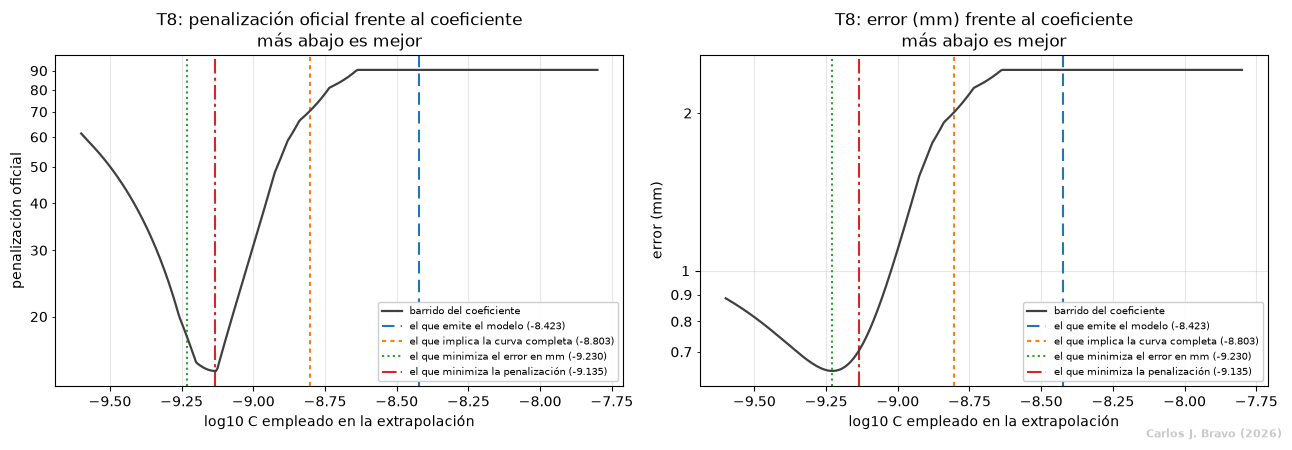

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, rot in ((axes[0], "penalizacion", "penalización oficial"),
                     (axes[1], "rmse_mm", "error (mm)")):
    ax.plot(barrido["log10_C"], barrido[col], color="0.25", lw=1.6, zorder=3,
            label="barrido del coeficiente")
    for nombre, log_c in candidatos.items():
        color, trazo = ESTILO[nombre]
        ax.axvline(log_c, color=color, ls=trazo, lw=1.5,
                   label=f"{nombre} ({log_c:.3f})")
    ax.set_yscale("log")
    eje_decimal(ax)
    ax.set_xlabel("log10 C empleado en la extrapolación")
    ax.set_ylabel(rot)
    ax.set_title(f"T8: {rot} frente al coeficiente\nmás abajo es mejor")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower right", framealpha=0.95)
cerrar(fig)


## 3. La entrega asimétrica

Se construye la entrega combinando las dos probetas: T7 con el coeficiente que su propio modelo
identifica, y T8 con cada uno de los candidatos. La comparación con las referencias del certamen se
incluye para dimensionar el margen, **no** para reclamar posición: las cifras de T8 proceden de
haber mirado su curva.

In [5]:
t7 = entregas["T7"]["penalizacion"]
filas = []
for _, r in tabla8.iterrows():
    filas.append({
        "coeficiente usado en T8": r["coeficiente"],
        "T7": round(t7, 2),
        "T8": r["penalización"],
        "total": round(t7 + r["penalización"], 2),
    })
combinada = pd.DataFrame(filas)
display(combinada)

print("Referencias (penalización oficial por espécimen):")
for etiqueta, v in REFERENCES.items():
    t7r = f"{v['T7']:8.2f}" if v["T7"] is not None else f"{'n/d':>8s}"
    t8r = f"{v['T8']:9.2f}" if v["T8"] is not None else f"{'n/d':>9s}"
    print(f"  {etiqueta:38s} T7 {t7r}   T8 {t8r}   total {v['total']:9.2f}")

,coeficiente usado en T8,T7,T8,total
0,el que emite el modelo,6.49,90.45,96.94
1,el que implica la curva completa,6.49,70.25,76.74
2,el que minimiza el error en mm,6.49,17.58,24.07
3,el que minimiza la penalización,6.49,14.34,20.83


Referencias (penalización oficial por espécimen):
  1.º Youn et al. (2019) (publicado)     T7     3.42   T8      3.94   total      7.36
  2.º Kong et al. (2020) (publicado)     T7     3.54   T8      4.09   total      7.63
  3.º Rao et al. (2020) (publicado)      T7     9.23   T8      6.86   total     16.09
  1.º Youn et al. (2019) (réplica local) T7    22.71   T8     91.60   total    114.31
  2.º Kong et al. (2020) (réplica local) T7    83.25   T8    148.34   total    231.60
  3.º Rao et al. (2020) (réplica local)  T7   215.12   T8     25.79   total    240.91


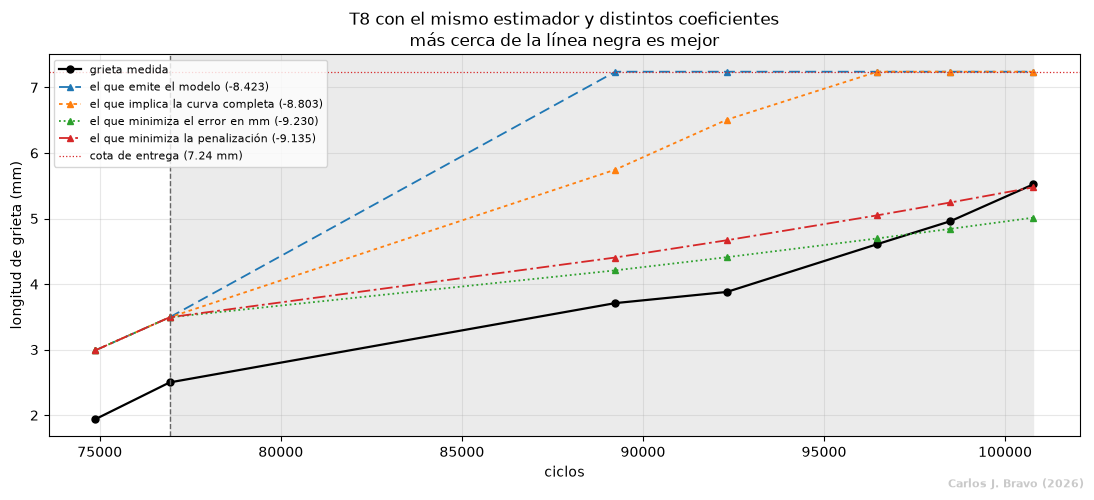

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ciclos = np.array(entregas["T8"]["cycles"], dtype=float)
corte = entregas["T8"]["cutoff_cycle"]
ax.axvspan(corte, ciclos.max(), color="0.92")
ax.plot(ciclos, entregas["T8"]["true_mm"], "k-o", lw=1.6, ms=5, label="grieta medida")
for nombre, log_c in candidatos.items():
    ax.plot(ciclos, trajectory(modelos, lotes, cfg, "T8", log_c), lw=1.3,
            color=ESTILO[nombre][0], ls=ESTILO[nombre][1], marker="^", ms=4,
            label=f"{nombre} ({log_c:.3f})")
ax.axvline(corte, color="0.4", lw=1.0, ls="--")
ax.axhline(cfg.cota_entrega_mm, color="tab:red", lw=0.9, ls=":",
           label=f"cota de entrega ({cfg.cota_entrega_mm:.2f} mm)")
ax.set_xlabel("ciclos")
ax.set_ylabel("longitud de grieta (mm)")
ax.set_title("T8 con el mismo estimador y distintos coeficientes\nmás cerca de la línea negra es mejor")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
cerrar(fig)

## 4. Lo que queda cuando el coeficiente ya no es el problema

La última fila de la tabla anterior es el techo alcanzable con este estimador: lo que obtendría la
Configuración 1 si algún mecanismo lograra identificar el coeficiente de T8 sin mirar su curva. La
diferencia entre ese techo y cero es lo que **no** se debe al coeficiente, y seguiría ahí: procede
de la estimación en la ventana con señal, que en T8 sobrestima ambas medidas, y del hecho de que el
anclaje de la extrapolación hereda ese error.

La celda siguiente separa las dos mitades de la entrega para cuantificarlo.

In [7]:
filas = []
for nombre, log_c in candidatos.items():
    pred = trajectory(modelos, lotes, cfg, "T8", log_c)
    origen = np.array(entregas["T8"]["source"])
    est, ext = origen == "estimación 1D-CNN", origen == "extrapolación Paris"
    filas.append({
        "coeficiente usado en T8": nombre,
        "penalización de la estimación": round(float(phm_penalty(
            pred[None, :][:, est], curva8.crack_mm[est], curva8.final_crack_mm)[0]), 2),
        "penalización de la prognosis": round(float(phm_penalty(
            pred[None, :][:, ext], curva8.crack_mm[ext], curva8.final_crack_mm)[0]), 2),
    })
display(pd.DataFrame(filas))

,coeficiente usado en T8,penalización de la estimación,penalización de la prognosis
0,el que emite el modelo,5.38,85.07
1,el que implica la curva completa,5.38,64.86
2,el que minimiza el error en mm,5.38,12.20
3,el que minimiza la penalización,5.38,8.96


## 5. Conclusiones

**El margen del coeficiente está cuantificado.** Con el estimador intacto y sustituyendo únicamente
el coeficiente de T8 por el que minimiza la penalización, su puntuación cae de noventa a unas
decenas, y el total de la entrega cae por debajo de todas las réplicas locales. Ése es el premio que
justifica seguir trabajando en la identificación del coeficiente, y es el objeto de las
Configuraciones 2 a 4.

**Una parte del error no es del coeficiente y no desaparece.** Incluso con el coeficiente óptimo
queda una penalización residual que procede de la mitad estimada: en T8 el codificador sobrestima
las dos medidas con señal, y la extrapolación arranca de ese anclaje ya desplazado. Ningún ajuste
del coeficiente lo corrige, porque actúa después.

**Nada de esto es entregable.** El coeficiente empleado aquí para T8 se obtiene de su curva real. El
resultado mide un techo, no un método, y así debe citarse. La pregunta que deja abierta, y que el
conjunto de datos no permite responder, es si ese coeficiente podría identificarse a partir de las
dos medidas de anclaje disponibles y del bloque de carga, sin ningún espécimen de carga variable en
entrenamiento.